In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
import plotly.express as px
import plotly.io as pio
import time
warnings.filterwarnings('ignore')

In [2]:
data=pd.read_csv('data.csv')

In [3]:
data.head(5)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [4]:
data.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_screen   2000

In [6]:
data.isna().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [7]:
data.duplicated().sum()

np.int64(0)

In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_screen   2000

In [9]:
data.nunique()

battery_power    1094
blue                2
clock_speed        26
dual_sim            2
fc                 20
four_g              2
int_memory         63
m_dep              10
mobile_wt         121
n_cores             8
pc                 21
px_height        1137
px_width         1109
ram              1562
sc_h               15
sc_w               19
talk_time          19
three_g             2
touch_screen        2
wifi                2
price_range         4
dtype: int64

## getting all the categical values and continiues value

In [10]:
cat_cols = [col for col in data.columns if data[col].nunique() == 2]
cont_cols = [col for col in data.columns if data[col].nunique() > 2]

In [11]:
cat_cols

['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi']

In [12]:
cont_cols

['battery_power',
 'clock_speed',
 'fc',
 'int_memory',
 'm_dep',
 'mobile_wt',
 'n_cores',
 'pc',
 'px_height',
 'px_width',
 'ram',
 'sc_h',
 'sc_w',
 'talk_time',
 'price_range']

In [ ]:
for col in cat_cols:
    # Get the value counts for the two categories
    val_counts = df[col].value_counts().reset_index()
    val_counts.columns = ['Category', 'Count']
    
    # Convert 'Category' to string to ensure the chart treats it as discrete
    val_counts['Category'] = val_counts['Category'].astype(str)
    
    # Create the bar chart
    fig = px.bar(val_counts, 
                 x='Category', 
                 y='Count', 
                 title=f'Counts of Unique Values for {col} (Binary)',
                 text='Count')
    
    # Update layout to ensure proper categorical representation
    fig.update_xaxes(type='category')
    
    # Save the file
    fig.write_image(f'output/binary_bar_{col}.png')

print(f"Generated charts for binary columns: {cat_cols}")

Generated charts for binary columns: ['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi']


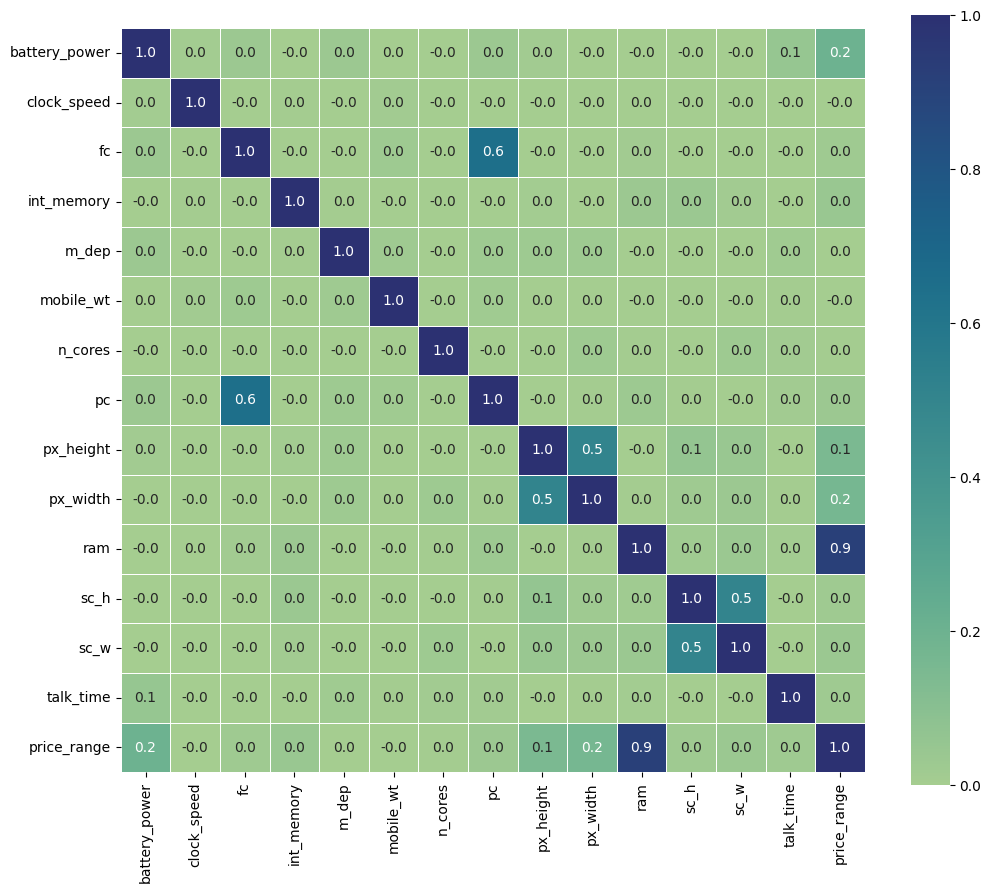

In [27]:
plt.figure(figsize=(12, 10))
sns.heatmap(data[cont_cols].corr(),
            annot=True,
            fmt=".1f",
            cmap='crest',
            vmin=0,
            vmax=1,
            linewidths=.5,
            square=True
            )

plt.show()

In [95]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay




In [49]:
X=data.drop('price_range',axis=1)
y=data['price_range']

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [35]:
cat_cols

['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi']

In [61]:
cont_cols

['battery_power',
 'clock_speed',
 'fc',
 'int_memory',
 'm_dep',
 'mobile_wt',
 'n_cores',
 'pc',
 'px_height',
 'px_width',
 'ram',
 'sc_h',
 'sc_w',
 'talk_time',
 'price_range']

In [36]:
data[['blue', 'dual_sim','four_g','three_g','touch_screen','wifi']] = data[['blue', 'dual_sim','four_g','three_g','touch_screen','wifi']].astype(object)


In [66]:
numeric_features = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = data.select_dtypes(include=['object']).columns.tolist()

In [67]:
numeric_features=[i for i in numeric_features if i !='price_range']
numeric_features

#categorical_features

['battery_power',
 'clock_speed',
 'fc',
 'int_memory',
 'm_dep',
 'mobile_wt',
 'n_cores',
 'pc',
 'px_height',
 'px_width',
 'ram',
 'sc_h',
 'sc_w',
 'talk_time']

In [68]:
# Numeric pipeline: impute → scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [69]:
# Categorical pipeline: impute → one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [70]:
# ColumnTransformer: apply different pipelines to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [71]:
# Full ML pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100))
])

In [80]:
# Full ML pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=100,      # Number of trees
        max_depth=6,           # Tree depth
        learning_rate=0.1,     # Step size
        random_state=42,
        eval_metric='mlogloss' # For multi-class (price_range 0-3)
    ))
])






In [81]:
# Fit and predict
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_pred):.2f}')

Accuracy: 0.90


In [96]:
# Get predictions from your pipeline
y_pred = pipeline.predict(X_test)

# Compute matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[ 94   5   0   0]
 [  7  86   5   0]
 [  0   4  74   7]
 [  0   0  14 104]]


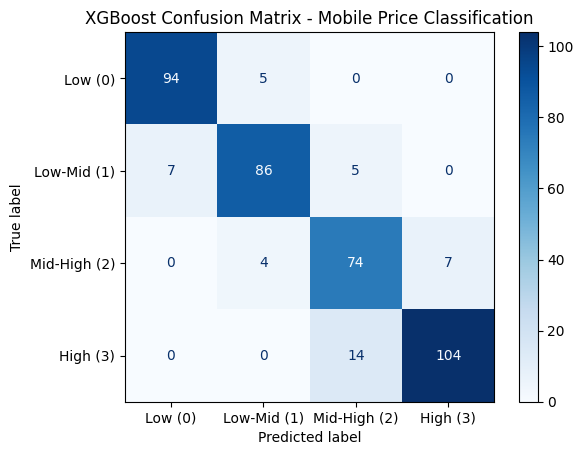

In [97]:
# Pretty plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=['Low (0)', 'Low-Mid (1)', 'Mid-High (2)', 'High (3)'])
disp.plot(cmap='Blues', values_format='d')
plt.title('XGBoost Confusion Matrix - Mobile Price Classification')
plt.show()

In [100]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

report = classification_report(y_test, y_pred, 
                              target_names=['Low (0)', 'Low-Mid (1)', 'Mid-High (2)', 'High (3)'])
print("\nPrecision, Recall, F1 per Class:")
print(report)


Precision, Recall, F1 per Class:
              precision    recall  f1-score   support

     Low (0)       0.93      0.95      0.94        99
 Low-Mid (1)       0.91      0.88      0.89        98
Mid-High (2)       0.80      0.87      0.83        85
    High (3)       0.94      0.88      0.91       118

    accuracy                           0.90       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.90      0.90      0.90       400

